In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import roc_auc_score
from sklearn.decomposition import PCA

# 중요도 판별
import eli5 
from eli5.sklearn import PermutationImportance 
from xgboost import XGBClassifier
from xgboost import plot_importance

# PyTorch 관련 import
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows: 맑은 고딕
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [22]:
train_val = pd.read_csv("train.csv")
display(train_val.head())

,Mass_Pilot,Width,Aspect,Inch,Plant,Proc_Param1,Proc_Param2,Proc_Param3,Proc_Param4,Proc_Param5,...,p247,p248,p249,p250,p251,p252,p253,p254,p255,Class
0,False,245,40,19,Plant_6,465.00,631.85,1460.8,1985,2059,...,1.475031,1.473817,1.472950,1.474981,1.477011,1.479157,1.483289,1.487421,1.491552,Good
1,False,275,40,21,Plant_2,516.01,701.87,1621.1,2205,2291,...,1.320114,1.326607,1.333636,1.340665,1.347694,1.352602,1.355859,1.359115,1.362371,Good
2,False,225,45,17,Plant_7,416.99,583.14,1310.0,1832,1918,...,1.344303,1.346259,1.348215,1.350183,1.352166,1.354149,1.356112,1.358066,1.360021,Good
3,True,275,30,20,Plant_7,490.01,623.89,1539.4,1960,2040,...,1.389538,1.389953,1.393673,1.397393,1.401113,1.405803,1.411120,1.416437,1.421754,Good
4,True,265,45,21,Plant_2,516.01,714.61,1621.1,2245,2336,...,1.435297,1.431648,1.428000,1.424352,1.420704,1.417607,1.415256,1.412904,1.410553,Good


In [ ]:
# 좌표 데이터 추출
xyp_value = train_val.iloc[:,31:]
display(xyp_value.head())
print(f"좌표 데이터 개수: {len(xyp_value)}")

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,...,p247,p248,p249,p250,p251,p252,p253,p254,p255,Class
0,239.886815,240.049079,240.211344,240.373608,240.535902,240.698242,240.860582,241.022921,241.191465,241.360307,...,1.475031,1.473817,1.472950,1.474981,1.477011,1.479157,1.483289,1.487421,1.491552,Good
1,265.197580,265.292190,265.386800,265.484497,265.582326,265.680142,265.777284,265.874426,265.971606,266.068888,...,1.320114,1.326607,1.333636,1.340665,1.347694,1.352602,1.355859,1.359115,1.362371,Good
2,214.748164,214.838477,214.928791,215.019739,215.111856,215.203972,215.295963,215.387721,215.479478,215.571219,...,1.344303,1.346259,1.348215,1.350183,1.352166,1.354149,1.356112,1.358066,1.360021,Good
3,251.893297,252.031334,252.169372,252.307409,252.445725,252.584944,252.724164,252.863383,253.002603,253.141128,...,1.389538,1.389953,1.393673,1.397393,1.401113,1.405803,1.411120,1.416437,1.421754,Good
4,265.088809,265.265819,265.442828,265.621792,265.801157,265.979895,266.156357,266.332819,266.520115,266.711078,...,1.435297,1.431648,1.428000,1.424352,1.420704,1.417607,1.415256,1.412904,1.410553,Good


좌표 데이터 개수: 720


In [ ]:
xyp_list = []

for sample_idx, row in xyp_value.iterrows():
    for i in range(1,256):
        xyp_list.append({
            "sample_idx": sample_idx,
            "x": row[f"x{i}"],
            "y": row[f"y{i}"],
            "p": row[f"p{i}"],
            'Class': row['Class']
        })

xyp_df = pd.DataFrame(xyp_list)
xyp_df.head()




,sample_idx,x,y,p,Class
0,0,239.886815,101.050016,1.100941,Good
1,0,240.049079,101.453623,1.197078,Good
2,0,240.211344,101.857229,1.293215,Good
3,0,240.373608,102.260835,1.389351,Good
4,0,240.535902,102.664430,1.469165,Good


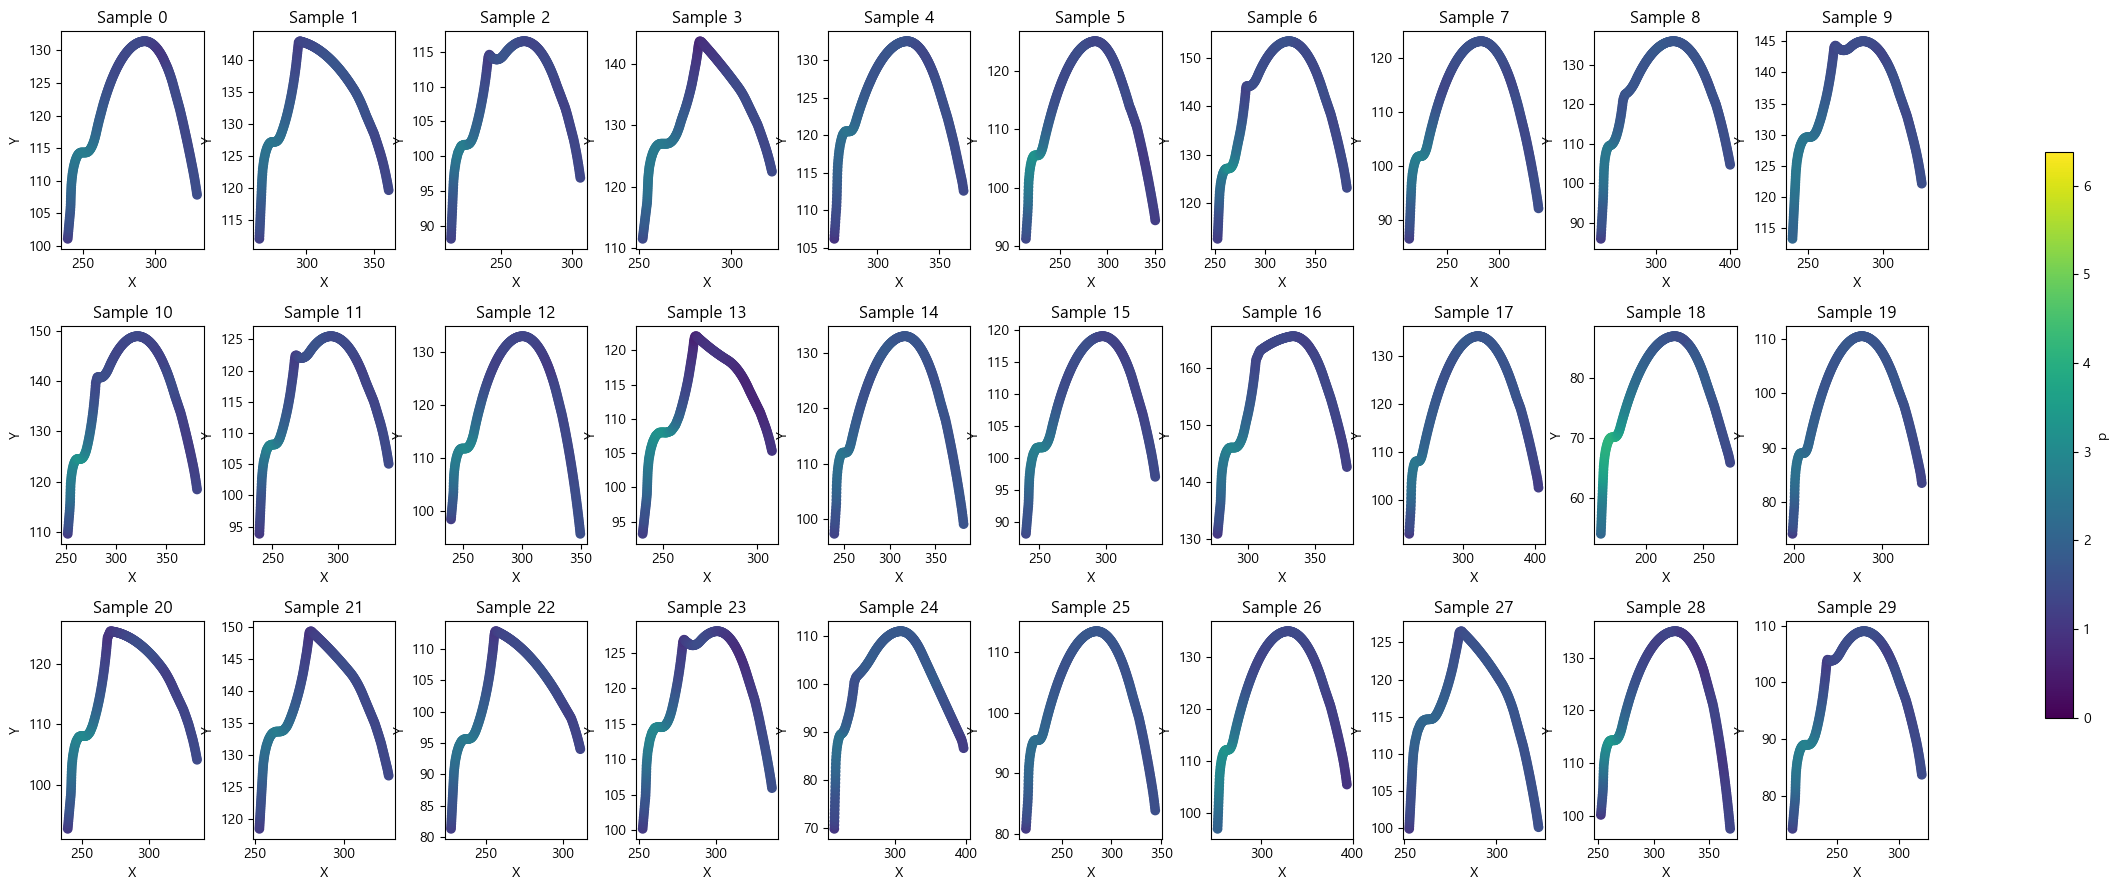

In [25]:
vmin = xyp_df["p"].min()
vmax = xyp_df["p"].max()

fig, axes = plt.subplots(3, 10, figsize=(30, 9))

for i, ax in enumerate(axes.ravel()):
    sample_df = xyp_df[xyp_df['sample_idx'] == i]
    
    sc = ax.scatter(
        sample_df['x'], sample_df['y'],
        c=sample_df['p'],
        cmap="viridis",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(f"Sample {i}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

fig.tight_layout()
fig.subplots_adjust(right=0.8)

cbar = fig.colorbar(sc, ax=axes, location="right", shrink=0.7)
cbar.set_label("p")

In [47]:
results = []

for i in range(256):
    sample_df = xyp_df[xyp_df['sample_idx'] == i]

    x_values = sample_df['x'].values
    y_values = sample_df['y'].values
    p_values = sample_df['p'].values
    class_values = sample_df['Class'].values

    # (N,2) 형태의 포인트
    points = np.vstack([x_values, y_values]).T

    # PCA 1D projection
    pca = PCA(n_components=1)
    coord_1d = pca.fit_transform(points).ravel()

    # 1D 좌표 기준 정렬
    order = np.argsort(coord_1d)

    x_sorted = x_values[order]
    y_sorted = y_values[order]
    p_sorted = p_values[order]
    coord_sorted = coord_1d[order]
    class_sorted = class_values[order]
    # 합쳐서 저장
    sample_result = pd.DataFrame({
        "sample_idx": i,
        "coord_1d": coord_sorted,
        "x": x_sorted,
        "y": y_sorted,
        "p": p_sorted,
        "Class": class_sorted
    })

    results.append(sample_result)

# 모든 sample concat
aligned_df = pd.concat(results, ignore_index=True)

In [48]:
print(aligned_df.head())

   sample_idx   coord_1d           x           y         p Class
0           0 -45.027801  239.886815  101.050016  1.100941  Good
1           0 -44.820662  240.049079  101.453623  1.197078  Good
2           0 -44.613524  240.211344  101.857229  1.293215  Good
3           0 -44.406386  240.373608  102.260835  1.389351  Good
4           0 -44.199220  240.535902  102.664430  1.469165  Good


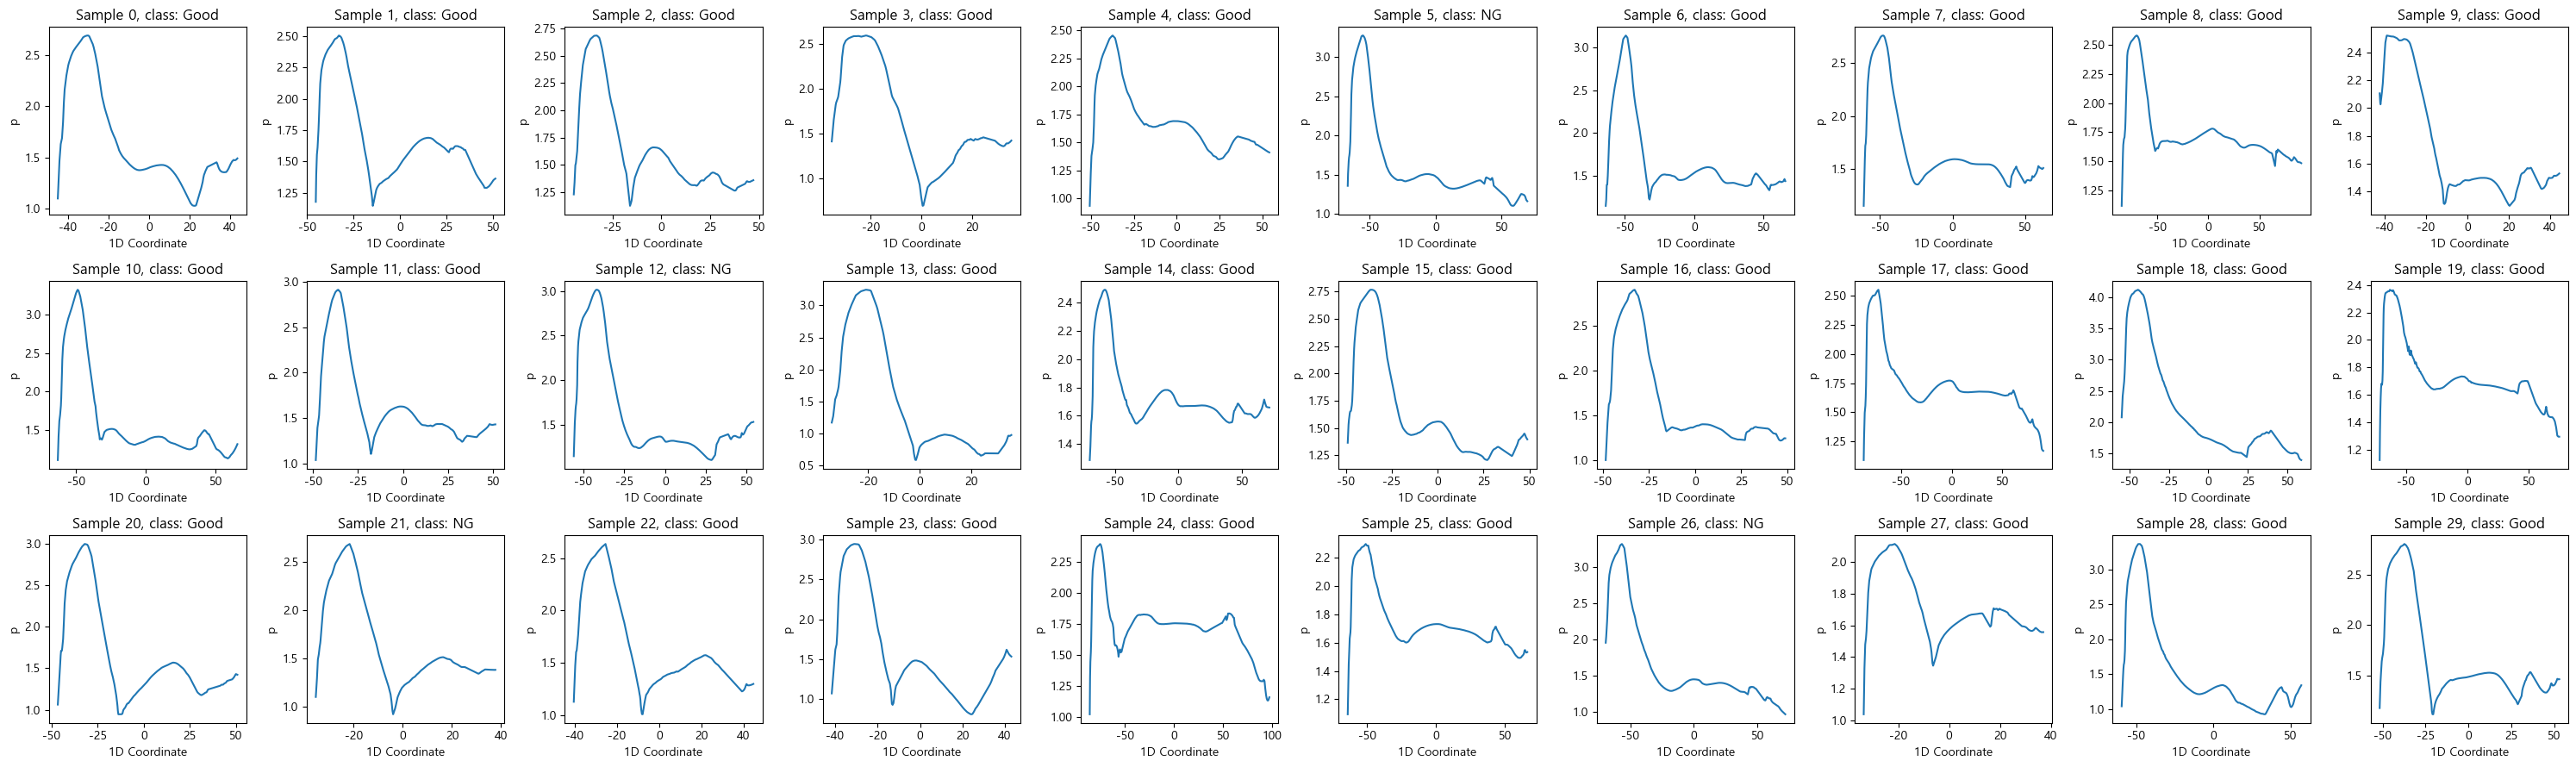

In [50]:
fig, axes = plt.subplots(3, 10, figsize=(30, 9))

for i, ax in enumerate(axes.ravel()):
    sample_df = aligned_df[aligned_df.sample_idx == i]
    ax.plot(sample_df.coord_1d, sample_df.p)
    ax.set_title(f"Sample {i}, class: {sample_df.iloc[0]['Class']}")
    ax.set_xlabel("1D Coordinate")
    ax.set_ylabel("p")

fig.tight_layout()
plt.show()

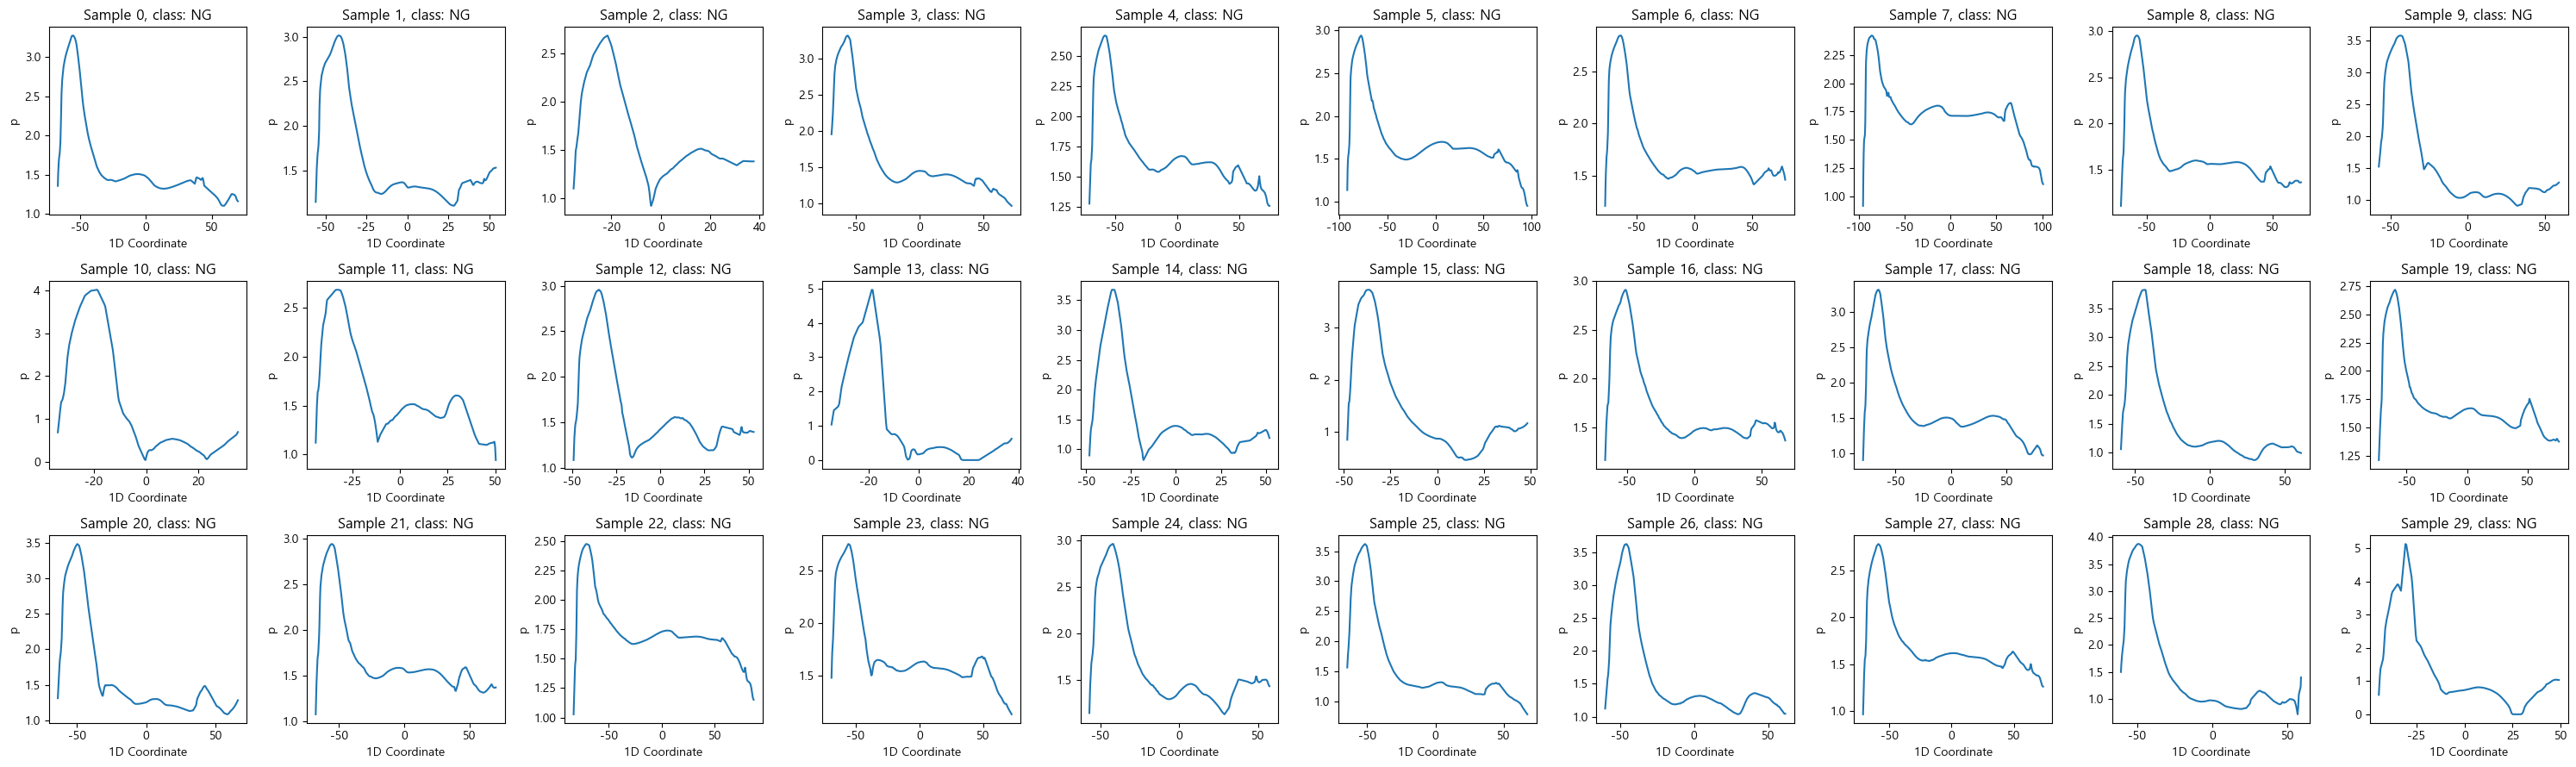

In [57]:
# NG class 확인
NG_aligned_df = aligned_df[aligned_df['Class'] == 'NG']

NG_sample_idx = NG_aligned_df['sample_idx'].unique()

fig, axes = plt.subplots(3, 10, figsize=(30, 9))

for i, ax in enumerate(axes.ravel()):
    sample_df = NG_aligned_df[NG_aligned_df.sample_idx == NG_sample_idx[i]]
    ax.plot(sample_df.coord_1d, sample_df.p)
    ax.set_title(f"Sample {i}, class: {sample_df.iloc[0]['Class']}")
    ax.set_xlabel("1D Coordinate")
    ax.set_ylabel("p")

fig.tight_layout()
plt.show()
